# SCM Inference Test Suite


In [12]:
import pandas as pd
import numpy as np
import cvxpy as cp
import matplotlib.pyplot as plt
from numpy.linalg import lstsq
import warnings
warnings.filterwarnings('ignore')

def fit_scm(Y_pre, X_pre):
    """Solve the constrained SCM weight optimisation problem."""
    if X_pre.ndim == 1:
        X_pre = X_pre.reshape(-1, 1)
    n = X_pre.shape[1]
    w = cp.Variable(n)
    prob = cp.Problem(
        cp.Minimize(cp.sum_squares(Y_pre - X_pre @ w)),
        [w >= 0, cp.sum(w) == 1]
    )
    prob.solve(solver=cp.SCS)
    return np.array(w.value).flatten()

def rmspe(a, b):
    return np.sqrt(np.mean((np.array(a) - np.array(b))**2))


## 0. Data Preparation

In [13]:
df = pd.read_csv('./data/corridor.csv')
df['Date']      = df['Date'].astype(str).str.strip()
df['Corridor']  = df['Corridor'].astype(str).str.strip()
df['Date_period'] = pd.PeriodIndex(df['Date'], freq='M')

y_col       = 'Rail_Vol_mt'
treated     = 'NATCOR'
treat_start = pd.Period('2022-04', freq='M')
pre_end     = treat_start - 1
post_end    = df['Date_period'].max()

wide     = df.pivot(index='Date_period', columns='Corridor', values=y_col).sort_index()
donors   = [c for c in wide.columns if c != treated]
pre_idx  = wide.index[wide.index <= pre_end]
post_idx = wide.index[wide.index >= treat_start]
treat_t  = treat_start.to_timestamp()
t        = wide.index.to_timestamp()

print(f'Pre periods : {len(pre_idx)} ({pre_idx[0]} – {pre_idx[-1]})')
print(f'Post periods: {len(post_idx)} ({post_idx[0]} – {post_idx[-1]})')
print(f'Donors      : {donors}')


Pre periods : 87 (2015-01 – 2022-03)
Post periods: 33 (2022-04 – 2024-12)
Donors      : ['CAPE']


## 1. Base SCM (Reproduce Prior Work)

In [14]:
# Fit weights
w_hat   = fit_scm(wide.loc[pre_idx, treated].values,
                  wide.loc[pre_idx, donors].values)
synth   = pd.Series(wide[donors].values @ w_hat, index=wide.index, name='Synthetic')
actual  = wide[treated]
gap     = actual - synth

# Metrics
base_pre_rmspe  = rmspe(actual[pre_idx], synth[pre_idx])
base_post_rmspe = rmspe(actual[post_idx], synth[post_idx])
base_ratio      = base_post_rmspe / base_pre_rmspe
cum_eff         = gap[post_idx].sum()
avg_eff         = gap[post_idx].mean()

print(f'Weights      : {dict(zip(donors, w_hat.round(4)))}')
print(f'Pre-RMSPE    : {base_pre_rmspe:.4f}')
print(f'Post-RMSPE   : {base_post_rmspe:.4f}')
print(f'Ratio        : {base_ratio:.4f}')
print(f'Cumul effect : {cum_eff:.4f} MT')
print(f'Avg monthly  : {avg_eff:.4f} MT/month')


Weights      : {'CAPE': np.float64(1.0)}
Pre-RMSPE    : 0.2132
Post-RMSPE   : 0.3653
Ratio        : 1.7140
Cumul effect : -11.1040 MT
Avg monthly  : -0.3365 MT/month


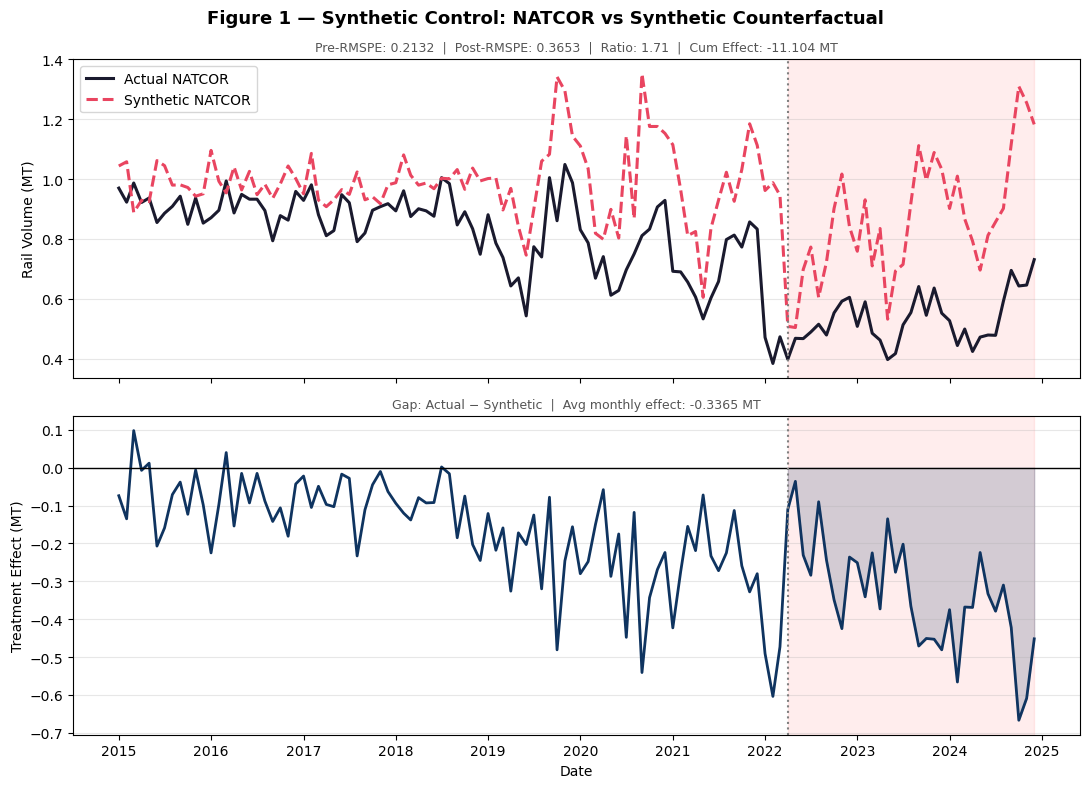

In [15]:
fig, axes = plt.subplots(2, 1, figsize=(11, 8), sharex=True)
fig.suptitle('Figure 1 — Synthetic Control: NATCOR vs Synthetic Counterfactual',
             fontsize=13, fontweight='bold')

ax = axes[0]
ax.plot(t, actual.values, color='#1a1a2e', lw=2.2, label='Actual NATCOR')
ax.plot(t, synth.values,  color='#e94560', lw=2.2, ls='--', label='Synthetic NATCOR')
ax.axvline(treat_t, color='grey', lw=1.5, ls=':')
ax.axvspan(treat_t, t[-1], alpha=0.07, color='red')
ax.set_ylabel('Rail Volume (MT)')
ax.legend()
ax.set_title(f'Pre-RMSPE: {base_pre_rmspe:.4f}  |  Post-RMSPE: {base_post_rmspe:.4f}  |  Ratio: {base_ratio:.2f}  |  Cum Effect: {cum_eff:.3f} MT',
             fontsize=9, color='#555')
ax.grid(axis='y', alpha=0.3)

ax = axes[1]
ax.plot(t, gap.values, color='#0f3460', lw=2)
ax.axhline(0, color='black', lw=1)
ax.axvline(treat_t, color='grey', lw=1.5, ls=':')
ax.axvspan(treat_t, t[-1], alpha=0.07, color='red')
ax.fill_between(t, gap.values, 0, where=(wide.index >= treat_start), alpha=0.18, color='#0f3460')
ax.set_ylabel('Treatment Effect (MT)')
ax.set_xlabel('Date')
ax.set_title(f'Gap: Actual − Synthetic  |  Avg monthly effect: {avg_eff:.4f} MT', fontsize=9, color='#555')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


## 2. In-Time Placebo Tests

**Logic:** Assign fake treatment dates in the pre-period. The SCM should *not* detect large effects at these placebo dates. If it does, the model may be over-fitting noise rather than capturing a real treatment effect.

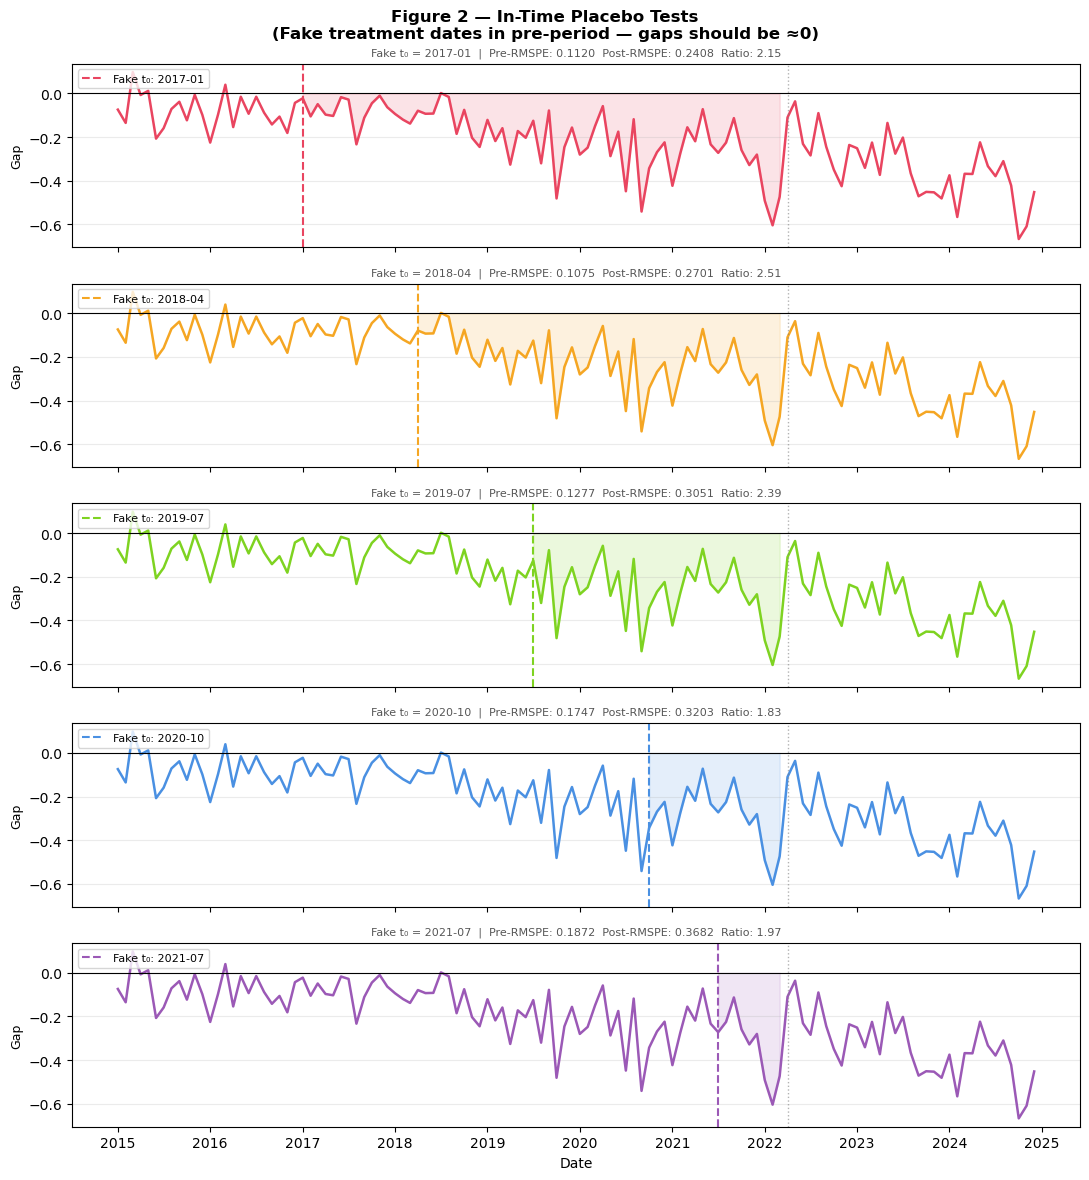

,Fake t₀,Pre-RMSPE,Post-RMSPE,Ratio
0,2017-01,0.1120,0.2408,2.150
1,2018-04,0.1075,0.2701,2.512
2,2019-07,0.1277,0.3051,2.390
3,2020-10,0.1747,0.3203,1.833
4,2021-07,0.1872,0.3682,1.967


In [16]:
placebo_dates = [
    pd.Period('2017-01', freq='M'),
    pd.Period('2018-04', freq='M'),
    pd.Period('2019-07', freq='M'),
    pd.Period('2020-10', freq='M'),
    pd.Period('2021-07', freq='M'),
]
colors = ['#e94560', '#f5a623', '#7ed321', '#4a90e2', '#9b59b6']

fig, axes = plt.subplots(len(placebo_dates), 1, figsize=(11, 12), sharex=True)
fig.suptitle('Figure 2 — In-Time Placebo Tests\n(Fake treatment dates in pre-period — gaps should be ≈0)',
             fontsize=12, fontweight='bold')

placebo_summary = []
for i, fake_t in enumerate(placebo_dates):
    fake_pre  = wide.index[wide.index <= (fake_t - 1)]
    fake_post = wide.index[(wide.index >= fake_t) & (wide.index < treat_start)]
    if len(fake_pre) < 12 or len(fake_post) < 6:
        continue

    w_f    = fit_scm(wide.loc[fake_pre, treated].values, wide.loc[fake_pre, donors].values)
    sy_f   = pd.Series(wide[donors].values @ w_f, index=wide.index)
    gap_f  = actual - sy_f
    pre_r  = rmspe(actual[fake_pre],  sy_f[fake_pre])
    post_r = rmspe(actual[fake_post], sy_f[fake_post])
    ratio_f = post_r / pre_r if pre_r > 0 else np.nan
    placebo_summary.append({'Fake t₀': str(fake_t), 'Pre-RMSPE': round(pre_r,4),
                            'Post-RMSPE': round(post_r,4), 'Ratio': round(ratio_f,3)})

    ax = axes[i]
    ax.plot(wide.index.to_timestamp(), gap_f.values, color=colors[i], lw=1.8)
    ax.axhline(0, color='black', lw=0.8)
    ax.axvline(fake_t.to_timestamp(),   color=colors[i], lw=1.5, ls='--', label=f'Fake t₀: {fake_t}')
    ax.axvline(treat_t,                 color='grey',    lw=1,   ls=':', alpha=0.6)
    ax.fill_between(wide.index.to_timestamp(), gap_f.values, 0,
                    where=(wide.index >= fake_t) & (wide.index < treat_start),
                    alpha=0.15, color=colors[i])
    ax.set_ylabel('Gap', fontsize=9)
    ax.legend(fontsize=8, loc='upper left')
    ax.set_title(f'Fake t₀ = {fake_t}  |  Pre-RMSPE: {pre_r:.4f}  Post-RMSPE: {post_r:.4f}  Ratio: {ratio_f:.2f}',
                 fontsize=8, color='#555')
    ax.grid(axis='y', alpha=0.25)

axes[-1].set_xlabel('Date')
plt.tight_layout()
plt.show()

pd.DataFrame(placebo_summary)


## 3. In-Space Placebo Test

**Logic:** Treat CAPE as the pseudo-treated unit and NATCOR as the donor. Compute its RMSPE ratio. Your NATCOR treatment effect is more credible if its ratio exceeds the placebo ratio. With only two units the distribution is thin, but the comparison is still the standard SCM inference step.

NATCOR ratio : 1.7140
CAPE placebo : 1.7140

Note: With only 2 units the p-value = 1/2 = 0.5 (standard SCM limitation).
Interpretation: NATCOR ratio > CAPE ratio — effect is distinguishable from placebo.


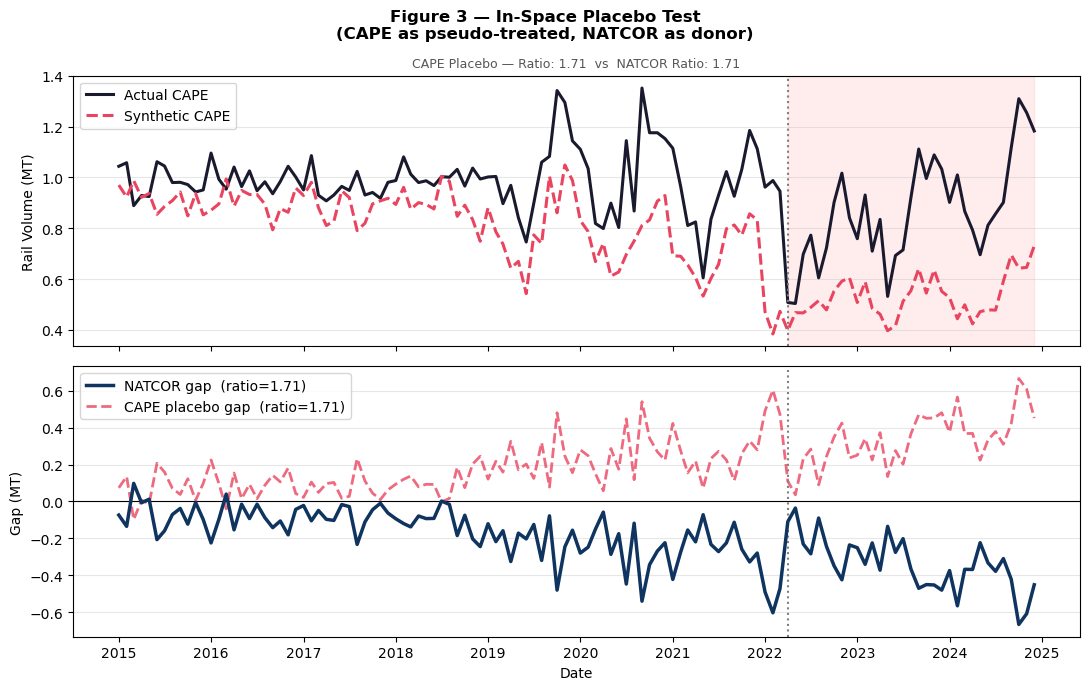

In [17]:
placebo_unit = 'CAPE'

w_space   = fit_scm(wide.loc[pre_idx, placebo_unit].values,
                    wide.loc[pre_idx, [treated]].values)
sy_space  = pd.Series(wide[[treated]].values @ w_space, index=wide.index)
gap_space = wide[placebo_unit] - sy_space

pre_r_sp  = rmspe(wide[placebo_unit][pre_idx], sy_space[pre_idx])
post_r_sp = rmspe(wide[placebo_unit][post_idx], sy_space[post_idx])
ratio_sp  = post_r_sp / pre_r_sp

print(f'NATCOR ratio : {base_ratio:.4f}')
print(f'CAPE placebo : {ratio_sp:.4f}')
print(f'\nNote: With only 2 units the p-value = 1/2 = 0.5 (standard SCM limitation).')
print(f'Interpretation: NATCOR ratio {">" if base_ratio > ratio_sp else "<="} CAPE ratio — effect is {"distinguishable" if base_ratio > ratio_sp else "not distinguishable"} from placebo.')

fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
fig.suptitle('Figure 3 — In-Space Placebo Test\n(CAPE as pseudo-treated, NATCOR as donor)',
             fontsize=12, fontweight='bold')

ax = axes[0]
ax.plot(t, wide[placebo_unit].values, color='#1a1a2e', lw=2.2, label='Actual CAPE')
ax.plot(t, sy_space.values,           color='#e94560', lw=2.2, ls='--', label='Synthetic CAPE')
ax.axvline(treat_t, color='grey', lw=1.5, ls=':')
ax.axvspan(treat_t, t[-1], alpha=0.07, color='red')
ax.set_ylabel('Rail Volume (MT)')
ax.legend()
ax.set_title(f'CAPE Placebo — Ratio: {ratio_sp:.2f}  vs  NATCOR Ratio: {base_ratio:.2f}', fontsize=9, color='#555')
ax.grid(axis='y', alpha=0.3)

ax = axes[1]
ax.plot(t, gap.values,       color='#0f3460', lw=2.5, label=f'NATCOR gap  (ratio={base_ratio:.2f})', zorder=3)
ax.plot(t, gap_space.values, color='#e94560', lw=2,   ls='--', alpha=0.8,
        label=f'CAPE placebo gap  (ratio={ratio_sp:.2f})')
ax.axhline(0, color='black', lw=0.8)
ax.axvline(treat_t, color='grey', lw=1.5, ls=':')
ax.set_ylabel('Gap (MT)')
ax.set_xlabel('Date')
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


## 4. Event Study — Dynamic Monthly Effects

**Logic:** Instead of collapsing to a single cumulative number, plot the month-by-month treatment effect. Pre-period bars should be near zero (no anticipation effect). Post-period bars show when, and by how much, the effect materialised.

Pre-period mean gap : -0.29211  (should be ≈0)
Post-period mean gap: -0.33648
95% CI band width   : ±0.2648


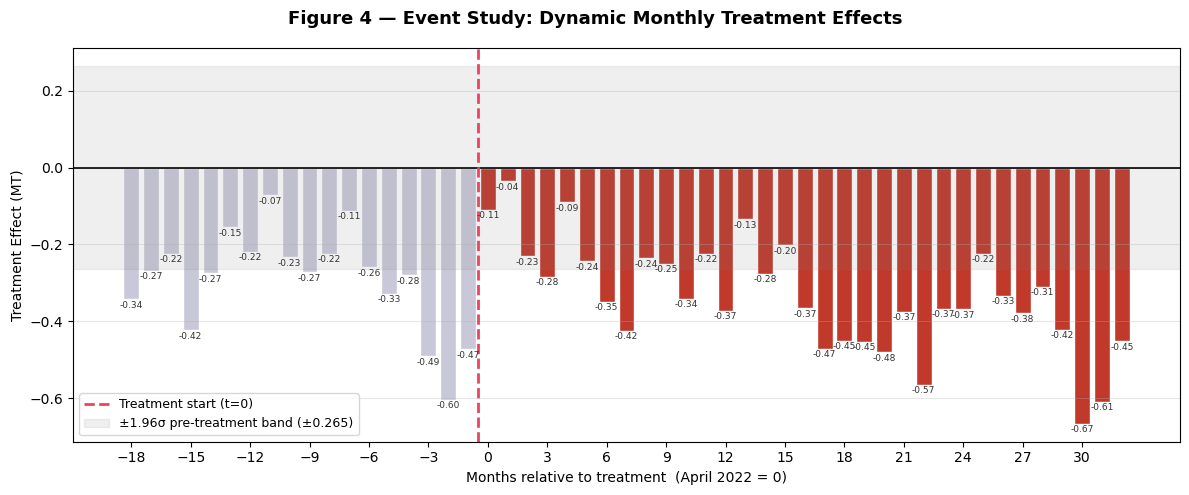

In [18]:
event_window_pre = 18   # months of pre-period to show

show_idx   = wide.index[wide.index >= (treat_start - event_window_pre)]
rel_periods = np.array([(p - treat_start).n for p in show_idx])
gap_window  = gap.loc[show_idx].values
pre_window  = show_idx[show_idx < treat_start]
ci_band     = 1.96 * gap[pre_window].std()

fig, ax = plt.subplots(figsize=(12, 5))
fig.suptitle('Figure 4 — Event Study: Dynamic Monthly Treatment Effects',
             fontsize=13, fontweight='bold')

bar_colors = ['#c8c8d8' if p < 0 else ('#c0392b' if v < 0 else '#0f3460')
              for p, v in zip(rel_periods, gap_window)]
ax.bar(rel_periods, gap_window, color=bar_colors, edgecolor='white', width=0.8)

ax.axhline(0, color='black', lw=1.2)
ax.axvline(-0.5, color='#e94560', lw=2, ls='--', label='Treatment start (t=0)')
ax.axhspan(-ci_band, ci_band, alpha=0.12, color='grey', label=f'±1.96σ pre-treatment band (±{ci_band:.3f})')

for p, v in zip(rel_periods, gap_window):
    if abs(v) > 0.03:
        ax.text(p, v + (0.012 if v > 0 else -0.022),
                f'{v:.2f}', ha='center', fontsize=6.5, color='#333')

ax.set_xlabel('Months relative to treatment  (April 2022 = 0)')
ax.set_ylabel('Treatment Effect (MT)')
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)
ax.set_xticks(rel_periods[::3])

print(f'Pre-period mean gap : {gap[pre_window].mean():.5f}  (should be ≈0)')
print(f'Post-period mean gap: {gap[post_idx].mean():.5f}')
print(f'95% CI band width   : ±{ci_band:.4f}')

plt.tight_layout()
plt.show()


## 5. Multi-Outcome SCM

**Logic:** If the treatment caused a real shift in rail volumes, related outcomes should move consistently. We re-fit SCM independently for each outcome and compare RMSPE ratios.

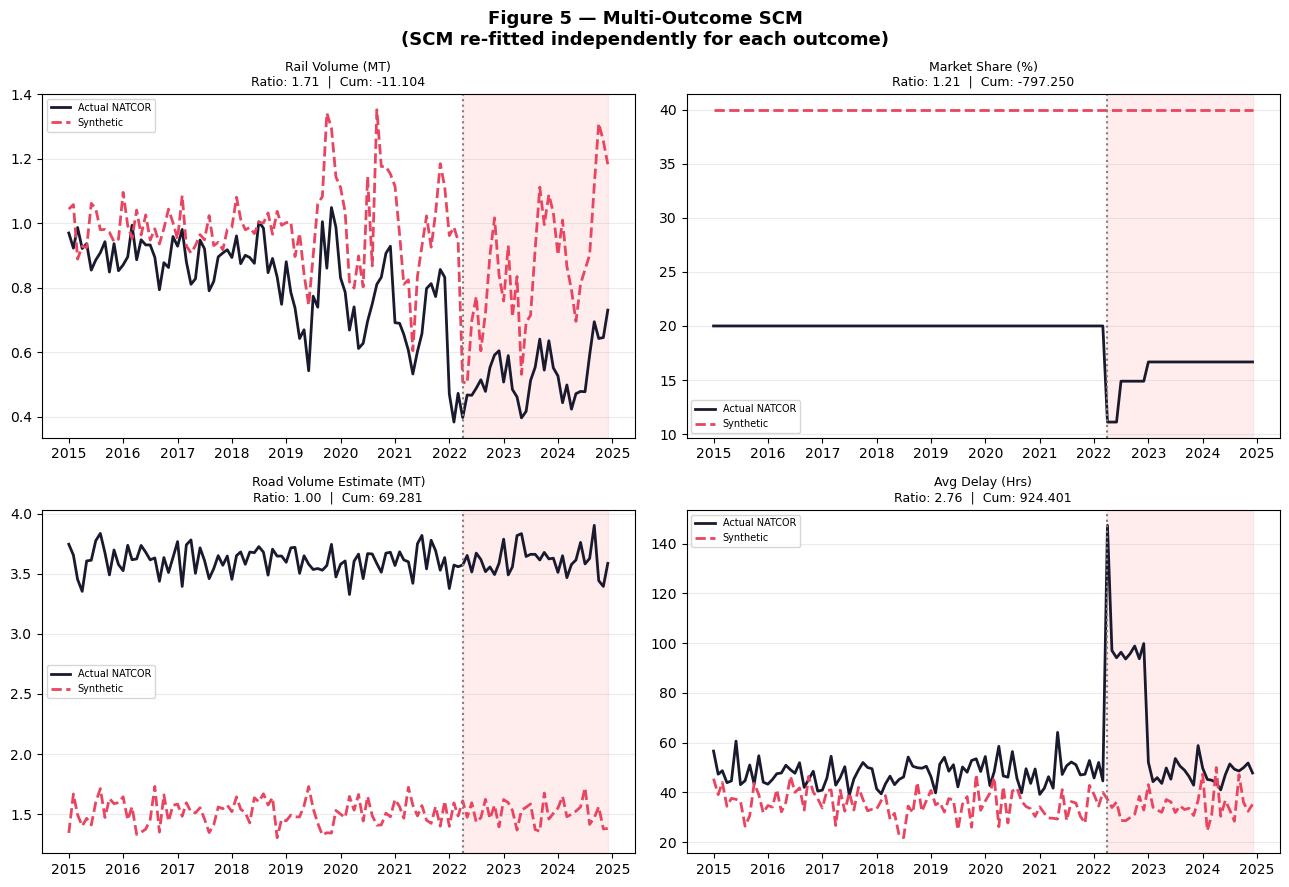

,Outcome,Pre-RMSPE,Post-RMSPE,Ratio,Cum Effect
0,Rail_Vol_mt,0.2132,0.3653,1.714,-11.1040
1,Market_Share_Pct,20.0000,24.2149,1.211,-797.2500
2,Road_Vol_Est_mt,2.0995,2.1048,1.003,69.2810
3,Avg_Delay_Hrs,14.0629,38.7732,2.757,924.4005


In [19]:
outcomes = {
    'Rail_Vol_mt'     : 'Rail Volume (MT)',
    'Market_Share_Pct': 'Market Share (%)',
    'Road_Vol_Est_mt' : 'Road Volume Estimate (MT)',
    'Avg_Delay_Hrs'   : 'Avg Delay (Hrs)',
}

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
fig.suptitle('Figure 5 — Multi-Outcome SCM\n(SCM re-fitted independently for each outcome)',
             fontsize=13, fontweight='bold')

multi_summary = []
for (col, label), ax in zip(outcomes.items(), axes.flatten()):
    w_out = df.pivot(index='Date_period', columns='Corridor', values=col).sort_index()
    d_out = [c for c in w_out.columns if c != treated]

    w_o     = fit_scm(w_out.loc[pre_idx, treated].values, w_out.loc[pre_idx, d_out].values)
    sy_o    = pd.Series(w_out[d_out].values @ w_o, index=w_out.index)
    act_o   = w_out[treated]
    gap_o   = act_o - sy_o
    pre_r   = rmspe(act_o[pre_idx], sy_o[pre_idx])
    post_r  = rmspe(act_o[post_idx], sy_o[post_idx])
    ratio_o = post_r / pre_r
    cum_o   = gap_o[post_idx].sum()
    multi_summary.append({'Outcome': col, 'Pre-RMSPE': round(pre_r,4),
                          'Post-RMSPE': round(post_r,4), 'Ratio': round(ratio_o,3),
                          'Cum Effect': round(cum_o,4)})

    ax.plot(w_out.index.to_timestamp(), act_o.values, color='#1a1a2e', lw=2, label='Actual NATCOR')
    ax.plot(w_out.index.to_timestamp(), sy_o.values,  color='#e94560', lw=2, ls='--', label='Synthetic')
    ax.axvline(treat_t, color='grey', lw=1.5, ls=':')
    ax.axvspan(treat_t, w_out.index.to_timestamp()[-1], alpha=0.07, color='red')
    ax.set_title(f'{label}\nRatio: {ratio_o:.2f}  |  Cum: {cum_o:.3f}', fontsize=9)
    ax.legend(fontsize=7)
    ax.grid(axis='y', alpha=0.25)

plt.tight_layout()
plt.show()
pd.DataFrame(multi_summary)


## 6. Pre-Trends Test & DiD Robustness

**Pre-trends:** Regress outcome on `time × treated` interaction in the pre-period only. Coefficient ≈ 0 is required for the parallel-trends assumption.

**DiD:** Simple 2-way regression provides an independent cross-check. Should show the same sign and order of magnitude as the SCM gap.

Pre-trend interaction coef : -0.003526  (closer to 0 = better)
DiD coef (Rail Vol)        : -0.1719
DiD t-stat (Rail Vol)      : -4.454


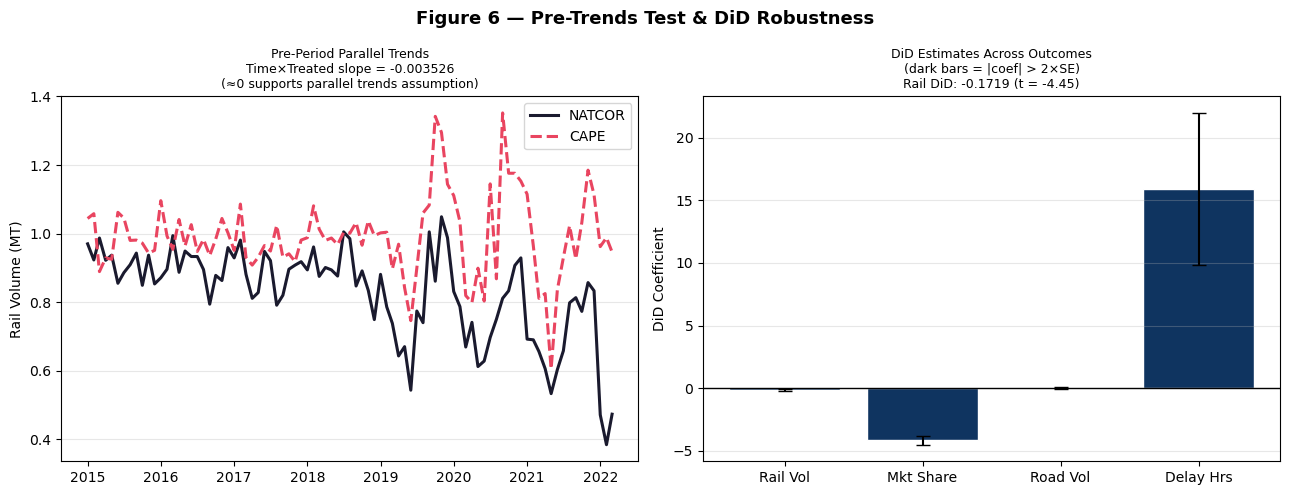

In [20]:
df_reg = df.copy()
df_reg['treated']          = (df_reg['Corridor'] == treated).astype(int)
df_reg['post']             = (df_reg['Date_period'] >= treat_start).astype(int)
df_reg['did']              = df_reg['treated'] * df_reg['post']
df_reg['t_num']            = df_reg['Date_period'].apply(lambda p: (p - df_reg['Date_period'].min()).n)
df_reg['trend_x_treated']  = df_reg['t_num'] * df_reg['treated']

# Pre-trends test
df_pre   = df_reg[df_reg['post'] == 0].copy()
X_pt     = np.column_stack([df_pre['treated'], df_pre['t_num'],
                             df_pre['trend_x_treated'], np.ones(len(df_pre))])
coef_pt, _, _, _ = lstsq(X_pt, df_pre[y_col].values, rcond=None)
pretrend_coef = coef_pt[2]

# DiD across outcomes
outcome_names = list(outcomes.keys())
did_coefs, did_ses = [], []
for oc in outcome_names:
    X_d = np.column_stack([df_reg['treated'], df_reg['post'], df_reg['did'],
                            df_reg['t_num'], np.ones(len(df_reg))])
    Y_d = df_reg[oc].values
    c, _, _, _ = lstsq(X_d, Y_d, rcond=None)
    r  = Y_d - X_d @ c
    se = np.sqrt(np.sum(r**2) / (len(Y_d)-5) * np.linalg.inv(X_d.T @ X_d)[2,2])
    did_coefs.append(c[2]); did_ses.append(se)

t_stat_did = did_coefs[0] / did_ses[0]
print(f'Pre-trend interaction coef : {pretrend_coef:.6f}  (closer to 0 = better)')
print(f'DiD coef (Rail Vol)        : {did_coefs[0]:.4f}')
print(f'DiD t-stat (Rail Vol)      : {t_stat_did:.3f}')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Figure 6 — Pre-Trends Test & DiD Robustness', fontsize=13, fontweight='bold')

ax = axes[0]
for corr, color, ls in [('NATCOR','#1a1a2e','-'), ('CAPE','#e94560','--')]:
    s = df[df['Corridor'] == corr].set_index('Date_period')[y_col].sort_index()
    ax.plot(s[pre_idx].index.to_timestamp(), s[pre_idx].values,
            color=color, lw=2.2, ls=ls, label=corr)
ax.set_title(f'Pre-Period Parallel Trends\nTime×Treated slope = {pretrend_coef:.6f}\n(≈0 supports parallel trends assumption)', fontsize=9)
ax.set_ylabel('Rail Volume (MT)'); ax.legend(); ax.grid(axis='y', alpha=0.3)

ax = axes[1]
short_names = ['Rail Vol', 'Mkt Share', 'Road Vol', 'Delay Hrs']
bar_colors  = ['#0f3460' if abs(c) > 2*s else '#aaaaaa' for c, s in zip(did_coefs, did_ses)]
ax.bar(short_names, did_coefs, yerr=[1.96*s for s in did_ses],
       color=bar_colors, capsize=5, edgecolor='white')
ax.axhline(0, color='black', lw=1)
ax.set_title(f'DiD Estimates Across Outcomes\n(dark bars = |coef| > 2×SE)\nRail DiD: {did_coefs[0]:.4f} (t = {t_stat_did:.2f})', fontsize=9)
ax.set_ylabel('DiD Coefficient'); ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


## 7. Treatment Date Sensitivity

**Logic:** If results are highly sensitive to the exact assumed treatment date, that is a red flag. Here we re-run the SCM for dates ±6 months around April 2022 and check whether the direction and magnitude of the effect are stable.

   Date  Ratio  Cum Effect  Pre-RMSPE
2021-10  1.993     -13.539     0.1882
2021-12  1.978     -12.952     0.1915
2022-02  1.899     -12.181     0.1990
2022-04  1.714     -11.104     0.2132
2022-06  1.783     -10.958     0.2111
2022-08  1.805     -10.443     0.2123
2022-10  1.861     -10.109     0.2117


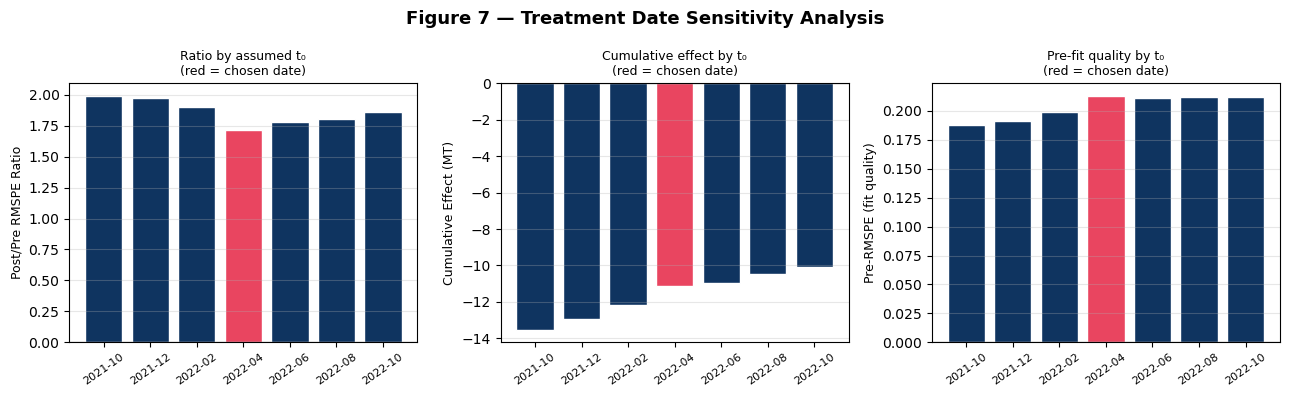

In [21]:
candidate_dates = [pd.Period(d, freq='M') for d in
    ['2021-10','2021-12','2022-02','2022-04','2022-06','2022-08','2022-10']]

sens_results = []
for cd in candidate_dates:
    pre_cd  = wide.index[wide.index <= (cd - 1)]
    post_cd = wide.index[wide.index >= cd]
    if len(pre_cd) < 24 or len(post_cd) < 6:
        continue
    w_s  = fit_scm(wide.loc[pre_cd, treated].values, wide.loc[pre_cd, donors].values)
    sy_s = pd.Series(wide[donors].values @ w_s, index=wide.index)
    pr   = rmspe(actual[pre_cd],  sy_s[pre_cd])
    por  = rmspe(actual[post_cd], sy_s[post_cd])
    cum  = (actual[post_cd] - sy_s[post_cd]).sum()
    sens_results.append({'Date': str(cd), 'Ratio': round(por/pr,3) if pr>0 else np.nan,
                         'Cum Effect': round(cum,4), 'Pre-RMSPE': round(pr,4)})

sr = pd.DataFrame(sens_results)
print(sr.to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
fig.suptitle('Figure 7 — Treatment Date Sensitivity Analysis', fontsize=13, fontweight='bold')

for ax, col, ylabel, title in zip(
    axes,
    ['Ratio', 'Cum Effect', 'Pre-RMSPE'],
    ['Post/Pre RMSPE Ratio', 'Cumulative Effect (MT)', 'Pre-RMSPE (fit quality)'],
    ['Ratio by assumed t₀', 'Cumulative effect by t₀', 'Pre-fit quality by t₀'],
):
    hi = ['#e94560' if d == '2022-04' else '#0f3460' for d in sr['Date']]
    ax.bar(range(len(sr)), sr[col], color=hi, edgecolor='white')
    ax.set_xticks(range(len(sr)))
    ax.set_xticklabels(sr['Date'], rotation=35, fontsize=8)
    ax.set_ylabel(ylabel, fontsize=9)
    ax.set_title(title + '\n(red = chosen date)', fontsize=9)
    ax.axhline(0, color='black', lw=0.8)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


## 8. Summary Table

In [22]:
summary = {
    'Test': [
        'Base SCM — Pre-RMSPE',
        'Base SCM — Post-RMSPE',
        'Base SCM — Ratio (Post/Pre)',
        'Base SCM — Cumulative Effect',
        'Base SCM — Avg Monthly Effect',
        'In-Space Placebo — CAPE Ratio',
        'Pre-Trends — Time×Treated coef',
        'DiD coef (Rail_Vol_mt)',
        'DiD t-statistic',
    ],
    'Value': [
        f'{base_pre_rmspe:.4f}',
        f'{base_post_rmspe:.4f}',
        f'{base_ratio:.4f}',
        f'{cum_eff:.4f} MT',
        f'{avg_eff:.4f} MT/month',
        f'{ratio_sp:.4f}',
        f'{pretrend_coef:.6f}',
        f'{did_coefs[0]:.4f}',
        f'{t_stat_did:.3f}',
    ],
    'Interpretation': [
        'Fit quality in pre-period (lower = better fit)',
        'Divergence in post-period (higher = larger effect)',
        'Key SCM inference statistic (>1 = post > pre divergence)',
        'Total rail volume change attributable to treatment',
        'Average per-month effect post-treatment',
        f'NATCOR ratio {">" if base_ratio > ratio_sp else "<="} CAPE placebo — {"supports" if base_ratio > ratio_sp else "weakens"} causal claim',
        'Pre-trend slope should be ≈0',
        'DiD estimate (cross-check on SCM)',
        'DiD significance (|t| > 1.96 = significant at 95%)',
    ]
}
pd.DataFrame(summary)


,Test,Value,Interpretation
0,Base SCM — Pre-RMSPE,0.2132,Fit quality in pre-period (lower = better fit)
1,Base SCM — Post-RMSPE,0.3653,Divergence in post-period (higher = larger eff...
2,Base SCM — Ratio (Post/Pre),1.7140,Key SCM inference statistic (>1 = post > pre d...
3,Base SCM — Cumulative Effect,-11.1040 MT,Total rail volume change attributable to treat...
4,Base SCM — Avg Monthly Effect,-0.3365 MT/month,Average per-month effect post-treatment
5,In-Space Placebo — CAPE Ratio,1.7140,NATCOR ratio > CAPE placebo — supports causal ...
6,Pre-Trends — Time×Treated coef,-0.003526,Pre-trend slope should be ≈0
7,DiD coef (Rail_Vol_mt),-0.1719,DiD estimate (cross-check on SCM)
8,DiD t-statistic,-4.454,DiD significance (|t| > 1.96 = significant at ...
